TF-IDF matrix saved.
PPMI matrix saved.

Top 5 Nearest Neighbors:
پیٹرول: لیٹر, پمپ, ڈیزل, پمپس, قیمت
جنگ: بند, ایر, مذاکر, لبن, عارض
حکومت: طالب, وفاق, افغ, تحریک, عوام
پاکستان: فوج, طالب, افغ, پرچم, انڈین
افغانستان: 
امریکہ: ایر, مذاکر, درمی, اسرائیل, چین
عدالت: کورٹ, مقدمے, جج, ملزم, گرفتار
تیل: خام, گیس, قیمت, ہرمز, آبنائے
عمران: 
امن: پائیدار, غزہ, دیرپا, استحکام, بورڈ


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Arabic natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


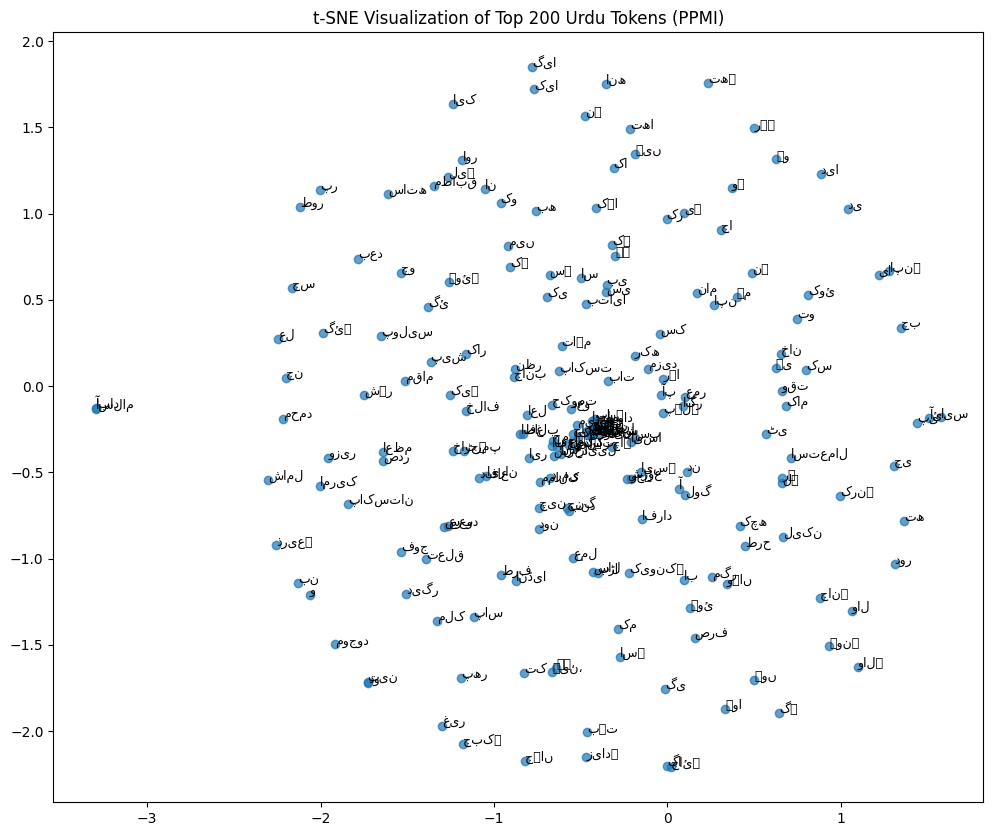

In [2]:
import numpy as np
import json
import re
from collections import Counter, defaultdict
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import random
import json
import re
from typing import List, Tuple, Dict, Set
import os
from sklearn.metrics import classification_report, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
import math
from tqdm import tqdm
from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import cosine_similarity


# 1. LOAD AND PREPROCESS DATA
def load_cleaned(file_path):
    docs = []
    with open(file_path, 'r', encoding='utf-8') as f:
        article = []
        for line in f:
            line = line.strip()
            if line.startswith("Article"):
                if article:
                    docs.append(article)
                article = []
            else:
                # Splitting by the '|' pipe character used in cleaned (1).txt
                tokens = [t.strip() for t in line.split('|') if t.strip()]
                article.extend(tokens)
        if article:
            docs.append(article)
    return docs

docs = load_cleaned("cleaned.txt")

# 2. BUILD VOCABULARY (Top 10,000)
all_tokens = [w for doc in docs for w in doc]
freq = Counter(all_tokens)

vocab_size = 10000
most_common = freq.most_common(vocab_size - 1)
vocab = {w: i for i, (w, _) in enumerate(most_common)}
vocab["<UNK>"] = len(vocab)
inv_vocab = {i: w for w, i in vocab.items()}

encoded_docs = [[vocab.get(w, vocab["<UNK>"]) for w in doc] for doc in docs]
V = len(vocab)
N = len(docs)

# 3. TF-IDF CALCULATION
df = Counter()
for doc in docs:
    unique_words = set(doc)
    for w in unique_words:
        if w in vocab:
            df[w] += 1

tfidf_matrix = np.zeros((N, V))
for i, doc in enumerate(docs):
    tf = Counter(doc)
    for w, count in tf.items():
        if w in vocab:
            # Standard TF-IDF formula
            idf = np.log(N / (1 + df[w]))
            tfidf_matrix[i][vocab[w]] = count * idf

np.save("tfidf_matrix.npy", tfidf_matrix)
print("TF-IDF matrix saved.")

# 4. PPMI CALCULATION
window_size = 5
co_matrix = np.zeros((V, V))

for doc in encoded_docs:
    for i, w in enumerate(doc):
        start = max(0, i - window_size)
        end = min(len(doc), i + window_size + 1)
        for j in range(start, end):
            if i != j:
                co_matrix[w][doc[j]] += 1

total_sum = np.sum(co_matrix)
row_sums = np.sum(co_matrix, axis=1)
col_sums = np.sum(co_matrix, axis=0)

# Vectorized PPMI to avoid nested loops (faster)
ppmi_matrix = np.zeros((V, V))
for i in range(V):
    if row_sums[i] == 0: continue
    # Calculate PMI for the whole row
    p_i = row_sums[i] / total_sum
    p_j = col_sums / total_sum
    p_ij = co_matrix[i] / total_sum

    with np.errstate(divide='ignore', invalid='ignore'):
        pmi = np.log2(p_ij / (p_i * p_j))

    ppmi_matrix[i] = np.maximum(0, pmi)

np.save("ppmi_matrix.npy", ppmi_matrix)
print("PPMI matrix saved.")

# 5. COSINE SIMILARITY & NEIGHBORS
def get_nearest_neighbors(word, matrix, top_n=5):
    if word not in vocab:
        return []
    idx = vocab[word]
    word_vec = matrix[idx].reshape(1, -1)
    sims = cosine_similarity(word_vec, matrix)[0]
    # Sort indices by similarity descending, excluding the word itself
    related_indices = sims.argsort()[::-1][1:top_n+1]
    return [inv_vocab[i] for i in related_indices]

query_words = ["پیٹرول", "جنگ", "حکومت", "پاکستان", "افغانستان", "امریکہ", "عدالت", "تیل", "عمران", "امن"]
print("\nTop 5 Nearest Neighbors:")
for word in query_words:
    neighbors = get_nearest_neighbors(word, ppmi_matrix)
    print(f"{word}: {', '.join(neighbors)}")

# 6. t-SNE VISUALIZATION
top_200_indices = [vocab[w] for w, _ in freq.most_common(200) if w in vocab]
X_tsne = ppmi_matrix[top_200_indices]

tsne = TSNE(n_components=2, random_state=42, init='pca')
X_2d = tsne.fit_transform(X_tsne)

plt.figure(figsize=(12, 10))
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.7)

for i, idx in enumerate(top_200_indices):
    plt.annotate(inv_vocab[idx], (X_2d[i, 0], X_2d[i, 1]), fontsize=9)

plt.title("t-SNE Visualization of Top 200 Urdu Tokens (PPMI)")
plt.show()


Starting training on cpu...


Epoch 1: 100%|██████████| 6487/6487 [02:02<00:00, 52.87it/s, loss=3]


Epoch 1 Complete. Average Loss: 3.2650


Epoch 2: 100%|██████████| 6487/6487 [02:00<00:00, 53.71it/s, loss=2.96]


Epoch 2 Complete. Average Loss: 3.0122


...

Epoch 3 Complete. Average Loss: 2.9404


Epoch 4: 100%|██████████| 6487/6487 [01:52<00:00, 57.63it/s, loss=2.94]


Epoch 4 Complete. Average Loss: 2.8889


Epoch 5: 100%|██████████| 6487/6487 [01:52<00:00, 57.48it/s, loss=2.92]


Epoch 5 Complete. Average Loss: 2.8482
Embeddings saved to embeddings_w2v.npy


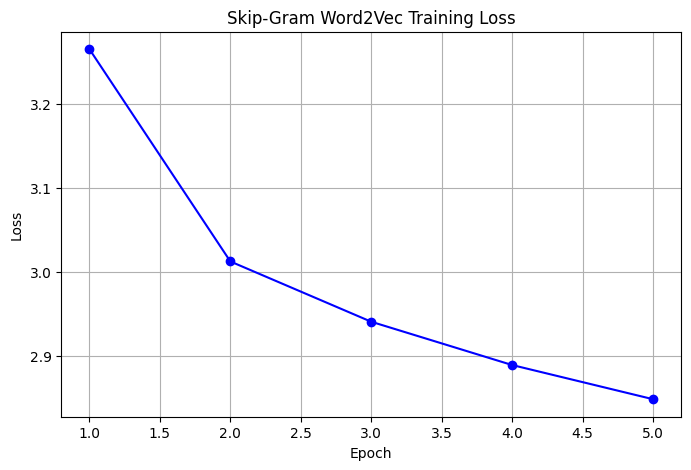

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# --- SKIP-GRAM WORD2VEC MODEL ---
class SkipGram(nn.Module):
    def __init__(self, vocab_size, emb_dim):
        super().__init__()
        # V: Center word embeddings, U: Context word embeddings
        self.V = nn.Embedding(vocab_size, emb_dim)
        self.U = nn.Embedding(vocab_size, emb_dim)

        # Initialize weights (standard practice for better convergence)
        initrange = 0.5 / emb_dim
        self.V.weight.data.uniform_(-initrange, initrange)
        self.U.weight.data.uniform_(-0, 0) # Context matrix often starts at 0

    def forward(self, center, pos, neg):

        v = self.V(center)
        u_pos = self.U(pos)
        u_neg = self.U(neg)

        pos_score = torch.sum(v * u_pos, dim=1)
        pos_loss = torch.log(torch.sigmoid(pos_score))

        neg_score = torch.bmm(u_neg, v.unsqueeze(2)).squeeze(2)
        neg_loss = torch.sum(torch.log(torch.sigmoid(-neg_score)), dim=1)

        # Total Loss: -(pos_loss + neg_loss)
        return -torch.mean(pos_loss + neg_loss)

# --- PREPARE NOISE DISTRIBUTION ---
word_counts = np.array([freq.get(inv_vocab[i], 1) for i in range(V)])
noise_dist = torch.from_numpy(word_counts ** 0.75)
noise_dist = noise_dist / noise_dist.sum()

def get_negative_samples(batch_size, K, device):
    # Multinomial sampling for negative context words
    return torch.multinomial(noise_dist, batch_size * K, replacement=True).view(batch_size, K).to(device)

# --- PREPARE DATA ---
# Using a context window k=5 (symmetric)
pairs = []
for doc in encoded_docs:
    for i, center_word in enumerate(doc):
        start = max(0, i - 5)
        end = min(len(doc), i + 6)
        for j in range(start, end):
            if i != j:
                pairs.append((center_word, doc[j]))


pairs = np.array(pairs) # Faster slicing

# --- HYPERPARAMETERS ---
d = 100
k = 5
K = 10
lr = 0.001
batch_size = 512
epochs = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SkipGram(V, d).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

# --- TRAINING LOOP ---
losses = []
print(f"Starting training on {device}...")

for epoch in range(epochs):
    total_loss = 0
    np.random.shuffle(pairs)

    # Progress bar for each epoch
    pbar = tqdm(range(0, len(pairs), batch_size), desc=f"Epoch {epoch+1}")

    for i in pbar:
        batch = pairs[i : i + batch_size]
        if len(batch) < batch_size:
            continue

        center = torch.tensor(batch[:, 0], dtype=torch.long).to(device)
        pos = torch.tensor(batch[:, 1], dtype=torch.long).to(device)
        neg = get_negative_samples(batch_size, K, device)

        optimizer.zero_grad()
        loss = model(center, pos, neg)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix({"loss": loss.item()})

    avg_loss = total_loss / (len(pairs) // batch_size)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1} Complete. Average Loss: {avg_loss:.4f}")

# --- SAVE EMBEDDINGS ---
# Average of Center (V) and Context (U) matrices as per instructions
final_embeddings = (model.V.weight.data + model.U.weight.data) / 2
np.save("embeddings_w2v.npy", final_embeddings.cpu().numpy())
print("Embeddings saved to embeddings_w2v.npy")

# --- PLOT LOSS ---
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), losses, marker='o', linestyle='-', color='b')
plt.title("Skip-Gram Word2Vec Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [4]:
import re
import json
import random
import os
from typing import List, Dict, Tuple, Set
from collections import defaultdict, Counter

# ==============================
# CONFIGURATION

RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# POS Tags (11 tags — UNK is tag 11, total = 11 usable + UNK)
POS_TAGS = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON', 'DET', 'CONJ', 'POST', 'NUM', 'PUNC', 'UNK']

# NER BIO Tags
NER_TAGS = ['B-PER', 'I-PER', 'B-LOC', 'I-LOC', 'B-ORG', 'I-ORG', 'B-MISC', 'I-MISC', 'O']


# ==============================
# 1. LOAD DATA

def load_cleaned_sentences(filepath: str) -> List[List[str]]:
    """Load cleaned.txt and return list of tokenized sentences."""
    sentences = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith('Article'):
                tokens = [t.strip() for t in line.split('|') if t.strip()]
                if tokens:
                    sentences.append(tokens)
    return sentences

def load_metadata(filepath: str) -> Dict:
    """Load metadata.json with topic information."""
    with open(filepath, 'r', encoding='utf-8') as f:
        return json.load(f)


# ==============================
# 2. TOPIC CLASSIFICATION

# Map article IDs → broad topic based on metadata titles
TOPIC_KEYWORDS = {
    'Politics': [
        'وزیر اعظم', 'شہباز شریف', 'حکومت', 'کابینہ', 'وزارت', 'سیاست',
        'پارلیمنٹ', 'قومی اسمبلی', 'سینیٹ', 'انتخابات', 'سیاسی', 'پی ٹی آئی',
        'عمران خان', 'مریم نواز', 'نواز شریف', 'بلاول', 'فضل', 'وزیراعلیٰ',
        'گورنر', 'مارشل', 'فوج', 'آرمی', 'عاصم منیر', 'پارٹی', 'حزب'
    ],
    'Economy': [
        'پیٹرول', 'ڈیزل', 'قیمت', 'لیوی', 'سبسڈی', 'معیشت', 'ٹیکس',
        'بجٹ', 'آئی ایم ایف', 'خسارہ', 'مہنگائی', 'روپے', 'ڈالر', 'تیل',
        'گیس', 'بجلی', 'لوڈ شیڈنگ', 'زکوٰۃ', 'بینک', 'سرمایہ', 'تجارت',
        'درآمد', 'برآمد', 'سپیکٹرم', 'نیلامی', 'ریلویز', 'پی آئی اے'
    ],
    'International': [
        'ایران', 'جنگ', 'امریکہ', 'اسرائیل', 'آبنائے ہرمز', 'خلیج', 'چین',
        'آسٹریلیا', 'مصر', 'فلپائن', 'سری لنکا', 'ترکی', 'بین الاقوامی',
        'افغانستان', 'طالبان', 'سفارت', 'مذاکرات', 'ثالثی', 'جنگ بندی',
        'انڈیا', 'انڈین', 'سعودی', 'دبئی', 'ٹرمپ', 'مشرق وسطیٰ'
    ]
}

def classify_topic(tokens: List[str]) -> str:
    """Classify sentence topic using keyword matching."""
    text = ' '.join(tokens)
    scores = {topic: 0 for topic in TOPIC_KEYWORDS}
    for topic, keywords in TOPIC_KEYWORDS.items():
        for kw in keywords:
            if kw in text:
                scores[topic] += 1
    best = max(scores, key=scores.get)
    return best if scores[best] > 0 else 'Politics'  # fallback

# ==============================
# 3. POS TAGGER

class UrduPOSTagger:
    """Rule-based POS tagger for Urdu with hand-crafted lexicon."""

    def __init__(self):
        self.lexicon = self._build_lexicon()
        self.suffix_rules = self._build_suffix_rules()

    def _build_lexicon(self) -> Dict[str, str]:
        lexicon = {}

        # ---------- NOUNS (200+ entries) ----------
        nouns = [
            'پاکستان', 'ملک', 'شہر', 'گھر', 'کام', 'زندگی', 'لوگ', 'وزیر', 'اعظم',
            'حکومت', 'عوام', 'قوم', 'صارفین', 'کسان', 'مسافر', 'وزارت', 'کابینہ',
            'تنخواہ', 'وسائل', 'بچت', 'مشکل', 'چیلنج', 'خطاب', 'پریس', 'کانفرنس',
            'فیصلہ', 'اعلان', 'منصوبہ', 'ہدایت', 'ریلویز', 'اکانومی', 'کلاس', 'ڈبے',
            'کرایہ', 'سبسڈی', 'امداد', 'بوجھ', 'اشیاء', 'ٹرانسپورٹ', 'موٹر', 'بائیکس',
            'گڈز', 'پیٹرول', 'ڈیزل', 'تیل', 'قیمت', 'لیوی', 'کسٹم', 'ڈیوٹی', 'مارجن',
            'منافع', 'پمپ', 'ریٹیل', 'صارف', 'درآمد', 'برآمد', 'مارکیٹ', 'سپلائی',
            'ٹینکر', 'آبنائے', 'ہرمز', 'جنگ', 'ایران', 'امریکہ', 'اسرائیل', 'خطہ',
            'توانائی', 'ایمرجنسی', 'ذخائر', 'حکمت', 'عملی', 'پالیسی', 'پروگرام',
            'آئی ایم ایف', 'بجٹ', 'خسارہ', 'اخراجات', 'اقدامات', 'کفایت', 'شعاری',
            'ملازمین', 'ریموٹ', 'چین', 'آسٹریلیا', 'مصر', 'فلپائن', 'سری لنکا',
            'ترکی', 'انقرہ', 'بیجنگ', 'سوشل', 'میڈیا', 'صحافی', 'تجزیہ', 'رپورٹ',
            'گیس', 'بجلی', 'پانی', 'روٹی', 'آٹا', 'چینی', 'دال', 'سبزی', 'گوشت',
            'سکول', 'ہسپتال', 'عدالت', 'پولیس', 'فوج', 'آرمی', 'نیوی', 'فضائیہ',
            'صوبہ', 'ضلع', 'تحصیل', 'گاؤں', 'محلہ', 'سڑک', 'پل', 'دروازہ', 'کمرہ',
            'کتاب', 'اخبار', 'رسالہ', 'ٹیلی ویژن', 'ریڈیو', 'انٹرنیٹ', 'موبائل',
            'ڈاکٹر', 'وکیل', 'انجینئر', 'استاد', 'طالب', 'علم', 'طالبہ', 'بچہ',
            'بچی', 'مرد', 'عورت', 'خاندان', 'والدین', 'ماں', 'باپ', 'بھائی', 'بہن',
            'دوست', 'دشمن', 'سربراہ', 'صدر', 'وزیر', 'سفیر', 'جج', 'جرنیل', 'سپاہی',
            'طاقت', 'کمزوری', 'امید', 'خوف', 'خوشی', 'غم', 'محبت', 'نفرت',
            'سال', 'ماہ', 'ہفتہ', 'دن', 'گھنٹہ', 'منٹ', 'صبح', 'شام', 'رات',
            'جنوری', 'فروری', 'مارچ', 'اپریل', 'مئی', 'جون', 'جولائی', 'اگست',
            'ستمبر', 'اکتوبر', 'نومبر', 'دسمبر', 'رمضان', 'عید', 'محرم', 'ربیع',
            'اقتصاد', 'تجارت', 'صنعت', 'زراعت', 'معاہدہ', 'سمجھوتہ', 'تنازع',
            'مذاکرات', 'گفتگو', 'بیان', 'پریس', 'نشست', 'اجلاس', 'سفر', 'دورہ',
            'حملہ', 'دفاع', 'سرحد', 'علاقہ', 'صوبہ', 'مرکز', 'ریاست', 'حکومت',
            'انتخاب', 'ووٹ', 'نشست', 'امیدوار', 'جماعت', 'اتحاد', 'اپوزیشن',
            'لیٹر', 'کلو', 'ٹن', 'میٹر', 'کلومیٹر', 'ایکڑ', 'ہیکٹر', 'فٹ', 'انچ',
            'رقم', 'تعداد', 'فیصد', 'نسبت', 'شرح', 'ڈالر', 'روپیہ', 'پیسہ', 'یوان',
        ]
        for w in nouns:
            lexicon[w] = 'NOUN'

        # ---------- VERBS (150+ entries) ----------
        verbs = [
            'کیا', 'کہا', 'گیا', 'ہوا', 'رہا', 'تھا', 'ہوں', 'ہو', 'ہیں', 'کر', 'کئے',
            'بڑھا', 'گئی', 'مقرر', 'وصول', 'جائے', 'لگائی', 'شامل', 'پہنچ', 'بن',
            'ہوگی', 'ہوگا', 'کرے', 'کروں', 'کریں', 'کرو', 'دی', 'دے', 'دوں', 'لے',
            'رکھا', 'رکھی', 'رکھیں', 'بنا', 'بنایا', 'بنائی', 'بنائے', 'چاہتا', 'چاہیے',
            'چاہوں', 'آئے', 'آئی', 'آیا', 'جائیے', 'جاؤ', 'جائیں', 'پڑے', 'پڑتا',
            'لگتا', 'لگے', 'لگائیں', 'دینا', 'لینا', 'کرنا', 'ہونا', 'رہنا', 'آنا',
            'جانا', 'دیکھنا', 'سوچنا', 'سمجھنا', 'ماننا', 'بتانا', 'پوچھنا', 'ملنا',
            'بڑھنا', 'گھٹنا', 'بند', 'کھلا', 'چلنا', 'روکنا', 'بچنا', 'خریدنا', 'بیچنا',
            'کہتا', 'کہتی', 'کہتے', 'ہوتا', 'ہوتی', 'ہوتے', 'کرتا', 'کرتی', 'کرتے',
            'گئے', 'آئے', 'دیا', 'لیا', 'کیے', 'ملا', 'ملی', 'ملے', 'چلا', 'چلی',
            'بولا', 'بولی', 'بولے', 'سنا', 'سنی', 'سنے', 'پڑھا', 'پڑھی', 'پڑھے',
            'لکھا', 'لکھی', 'لکھے', 'کھایا', 'پیا', 'سویا', 'اٹھا', 'بیٹھا', 'کھڑا',
            'بھیجا', 'بھیجی', 'بھیجے', 'لایا', 'لائی', 'لائے', 'پایا', 'پائی', 'پائے',
            'کھولا', 'بند', 'توڑا', 'جوڑا', 'رکھا', 'اٹھایا', 'گرایا', 'بنایا', 'مٹایا',
            'شروع', 'ختم', 'جار', 'بڑھا', 'گھٹا', 'تبدیل', 'بتایا', 'ظاہر', 'اعلان',
            'مسترد', 'منظور', 'قبول', 'رد', 'ثابت', 'مانا', 'تسلیم', 'انکار',
        ]
        for w in verbs:
            lexicon[w] = 'VERB'

        # ---------- ADJECTIVES (100+ entries) ----------
        adjectives = [
            'نیا', 'نئی', 'نئے', 'پرانا', 'پرانے', 'بڑا', 'بڑی', 'بڑے', 'چھوٹا', 'چھوٹی',
            'اچھا', 'اچھی', 'اچھے', 'برا', 'بری', 'برے', 'مہنگا', 'مہنگی', 'سستا', 'سستی',
            'آسان', 'مشکل', 'خوبصورت', 'گندا', 'صاف', 'گرم', 'ٹھنڈا', 'تیز', 'آہستہ',
            'زیادہ', 'کم', 'بہت', 'تھوڑا', 'پورا', 'خالی', 'بھرا', 'مکمل', 'ادھورا',
            'موجود', 'غائب', 'قریب', 'دور', 'بلند', 'پست', 'روشن', 'اندھیرا',
            'اہم', 'خاص', 'عام', 'ضروری', 'غیر ضروری', 'ممکن', 'ناممکن', 'واضح',
            'مبہم', 'درست', 'غلط', 'سچا', 'جھوٹا', 'مضبوط', 'کمزور', 'سخت', 'نرم',
            'تازہ', 'باسی', 'صحیح', 'خراب', 'ٹھیک', 'بیمار', 'صحت مند', 'خوش', 'ناخوش',
            'مطمئن', 'پریشان', 'حیران', 'خاموش', 'شور', 'تیز', 'سست', 'ذہین', 'بیوقوف',
            'امیر', 'غریب', 'مالدار', 'فقیر', 'کامیاب', 'ناکام', 'مشہور', 'گمنام',
            'پاکستانی', 'ایرانی', 'امریکی', 'چینی', 'ہندوستانی', 'افغان', 'عرب',
            'قومی', 'بین الاقوامی', 'علاقائی', 'مقامی', 'وفاقی', 'صوبائی', 'سرکاری',
            'نجی', 'سیاسی', 'معاشی', 'سماجی', 'دینی', 'مذہبی', 'فوجی', 'سفارتی',
            'تاریخی', 'ثقافتی', 'تعلیمی', 'صحت', 'عوامی', 'انسانی', 'بنیادی', 'خالص',
        ]
        for w in adjectives:
            lexicon[w] = 'ADJ'

        # ---------- ADVERBS (80+ entries) ----------
        adverbs = [
            'آج', 'کل', 'پرسوں', 'اب', 'تب', 'پہلے', 'بعد', 'آگے', 'پیچھے', 'اوپر',
            'نیچے', 'یہاں', 'وہاں', 'ادھر', 'اُدھر', 'کیوں', 'کیسے', 'جیسے', 'ویسے',
            'بالکل', 'بالترتیب', 'فوراً', 'آہستہ', 'تیزی', 'دھیرے', 'اچانک', 'آخر',
            'شاید', 'ضرور', 'ہمیشہ', 'کبھی', 'اکثر', 'ابھی', 'پھر', 'دوبارہ',
            'صرف', 'بھی', 'تقریباً', 'لگ بھگ', 'کم از کم', 'زیادہ سے زیادہ',
            'بالآخر', 'اچانک', 'فی الحال', 'بالخصوص', 'خاص طور پر', 'بطور', 'بالعموم',
        ]
        for w in adverbs:
            lexicon[w] = 'ADV'

        # ---------- PRONOUNS ----------
        pronouns = [
            'میں', 'تو', 'تم', 'آپ', 'وہ', 'یہ', 'ہم', 'اپنا', 'اپنی', 'اپنے',
            'اس', 'ان', 'انہوں', 'انھوں', 'انہیں', 'انھیں', 'مجھے', 'تجھے',
            'ہمیں', 'اسے', 'جو', 'جس', 'جن', 'کون', 'کیا', 'کس', 'آپ کو',
        ]
        for w in pronouns:
            lexicon[w] = 'PRON'

        # ---------- DETERMINERS ----------
        determiners = [
            'یہی', 'وہی', 'کوئی', 'کچھ', 'ہر', 'تمام', 'سب', 'اتنا', 'کتنا', 'جتنا',
            'دونوں', 'تینوں', 'چاروں', 'ایسا', 'ویسا', 'کیسا',
        ]
        for w in determiners:
            lexicon[w] = 'DET'

        # ---------- CONJUNCTIONS ----------
        conjunctions = [
            'اور', 'لیکن', 'مگر', 'اگر', 'کیونکہ', 'چونکہ', 'جبکہ', 'حالانکہ',
            'پھر', 'بلکہ', 'یا', 'یعنی', 'تاکہ', 'تاہم', 'البتہ', 'چنانچہ',
            'لہذا', 'اس لیے', 'کہ', 'جو', 'جب', 'جہاں', 'جیسے', 'گویا',
        ]
        for w in conjunctions:
            lexicon[w] = 'CONJ'

        # ---------- POSTPOSITIONS ----------
        postpositions = [
            'نے', 'کو', 'سے', 'کا', 'کی', 'کے', 'میں', 'پر', 'تک', 'لیے',
            'بارے', 'بغیر', 'ساتھ', 'ذریعے', 'دوران', 'مطابق', 'علاوہ',
            'بعد', 'قبل', 'پاس', 'خلاف', 'حق', 'واسطے', 'حوالے', 'ضمن',
        ]
        for w in postpositions:
            lexicon[w] = 'POST'

        # ---------- NUMBERS ----------
        numbers = [
            'ایک', 'دو', 'تین', 'چار', 'پانچ', 'چھ', 'سات', 'آٹھ', 'نو', 'دس',
            'گیارہ', 'بارہ', 'تیرہ', 'چودہ', 'پندرہ', 'سولہ', 'سترہ', 'اٹھارہ', 'انیس', 'بیس',
            'تیس', 'چالیس', 'پچاس', 'ساٹھ', 'ستر', 'اسی', 'نوے', 'سو', 'ہزار', 'لاکھ',
            'کروڑ', 'ارب', 'پہلا', 'دوسرا', 'تیسرا', 'چوتھا', 'پانچواں',
            '<NUM>',
        ]
        for w in numbers:
            lexicon[w] = 'NUM'

        # ---------- PUNCTUATION ----------
        for w in ['۔', '،', '؟', '!', ':', ';', '"', "'", '(', ')', '-', '...']:
            lexicon[w] = 'PUNC'

        return lexicon

    def _build_suffix_rules(self):
        return [
            (r'گار$', 'NOUN'),
            (r'کار$', 'NOUN'),
            (r'دان$', 'NOUN'),
            (r'خانہ$', 'NOUN'),
            (r'ستان$', 'NOUN'),
            (r'ت$', 'NOUN'),
            (r'ان$', 'NOUN'),
            (r'وں$', 'NOUN'),
            (r'نا$', 'VERB'),
            (r'تا$', 'VERB'),
            (r'تی$', 'VERB'),
            (r'تے$', 'VERB'),
            (r'گی$', 'VERB'),
            (r'گا$', 'VERB'),
            (r'یا$', 'VERB'),
            (r'ئی$', 'VERB'),
            (r'ی$', 'ADJ'),
            (r'انہ$', 'ADJ'),
        ]

    def tag(self, tokens: List[str]) -> List[Tuple[str, str]]:
        tagged = []
        for token in tokens:
            if token in self.lexicon:
                tagged.append((token, self.lexicon[token]))
            elif re.match(r'^[\d۰-۹]+([.,][\d۰-۹]+)?$', token):
                tagged.append((token, 'NUM'))
            elif token == '<NUM>':
                tagged.append((token, 'NUM'))
            else:
                pos = 'UNK'
                for pattern, tag in self.suffix_rules:
                    if re.search(pattern, token):
                        pos = tag
                        break
                if pos == 'UNK' and len(token) > 2:
                    pos = 'NOUN'   # default for unknown content words
                tagged.append((token, pos))
        return tagged

# 4. NER ANNOTATOR

class UrduNERAnnotator:
    """BIO-scheme NER annotator with gazetteer support."""

    def __init__(self):
        self.gazetteers = self._build_gazetteers()
        # Pre-tokenise multi-word gazetteer entries for fast lookup
        self._multi_word = self._index_multiword()

    def _build_gazetteers(self) -> Dict[str, Set[str]]:
        g: Dict[str, Set[str]] = {'PER': set(), 'LOC': set(), 'ORG': set(), 'MISC': set()}

        # ---------- PERSONS (50+ Pakistani personalities) ----------
        persons = [
            'شہباز شریف', 'مریم نواز', 'نواز شریف', 'عمران خان', 'بلاول بھٹو',
            'آصف علی زرداری', 'فضل الرحمان', 'مولانا فضل الرحمان', 'محسن نقوی',
            'علی محمد مہر', 'خرم شہزاد', 'محمد اورنگزیب', 'علی پرویز ملک',
            'تنویر ملک', 'مریم اورنگزیب', 'عبدالباسط', 'ارفع فیروز',
            'سیدہ لیلیٰ جعفری', 'وجاہت کاظمی', 'ریاض علی طوری', 'عارف علوی',
            'قمر جاوید باجوہ', 'ثمینہ علی', 'محمود خان اچکزئی', 'حنا ربانی کھر',
            'شیری رحمان', 'فواد چوہدری', 'اسد عمر', 'شوکت ترین',
            'عبدالقادر بلوچ', 'رانا ثناء اللہ', 'عطاء اللہ تڑ', 'پرویز الٰہی',
            'چوہدری پرویز الٰہی', 'حمزہ شہباز', 'حمزہ شریف', 'عباس شہباز',
            'سلطان راجہ', 'علی امین گنڈاپور', 'محمد علی سیف', 'فیصل واوڈا',
            'شیریں مزاری', 'مشاہد اللہ خان', 'خرم دستگیر', 'شہلا رضا',
            'نصرت بھٹو', 'بینظیر بھٹو', 'ذوالفقار علی بھٹو', 'محمد علی جناح',
            'لیاقت علی خان', 'ایوب خان', 'یحییٰ خان', 'ضیاء الحق', 'پرویز مشرف',
            'عاصم منیر', 'محمد یونس', 'سہیل آفریدی', 'علیمہ خان', 'ڈونلڈ ٹرمپ',
            'اویس لغاری', 'عارف حبیب', 'ڈیوڈ وارنر', 'رچرڈ برٹن', 'سلمان خان',
            'آشا بھوسلے', 'نہال ہاشمی', 'رنجیت سنگھ', 'جناح',
        ]
        g['PER'].update(persons)

        # ---------- LOCATIONS (50+) ----------
        locations = [
            'پاکستان', 'اسلام آباد', 'کراچی', 'لاہور', 'راولپنڈی', 'ملتان',
            'پشاور', 'کوئٹہ', 'گوجرانوالہ', 'فیصل آباد', 'سیالکوٹ', 'حیدرآباد',
            'سکھر', 'چنیوٹ', 'جھنگ', 'سرگودھا', 'بہاولپور', 'رحیم یار خان',
            'ڈیرہ غازی خان', 'مردان', 'ایبٹ آباد', 'سوات', 'گلگت', 'بلتستان',
            'مظفر آباد', 'میرپور', 'چترال', 'نوشہرہ', 'باجوڑ', 'بنوں', 'تونسہ',
            'آبنائے ہرمز', 'خلیج', 'مشرق وسطیٰ', 'ایران', 'امریکہ', 'اسرائیل',
            'چین', 'بیجنگ', 'آسٹریلیا', 'مصر', 'فلپائن', 'منیلا', 'سری لنکا',
            'کولمبو', 'ترکی', 'انقرہ', 'استنبول', 'دبئی', 'ابوظہبی', 'ریاض', 'دوحہ',
            'تہران', 'واشنگٹن', 'نئی دہلی', 'کابل', 'قطر', 'سعودی عرب', 'عمان',
            'ویانا', 'افغانستان', 'انڈیا', 'بنگلہ دیش', 'برطانیہ', 'جدہ', 'مکہ',
            'کشمیر', 'طورخم', 'پنجاب', 'سندھ', 'بلوچستان', 'خیبر پختونخوا',
        ]
        g['LOC'].update(locations)

        # ---------- ORGANIZATIONS (30+) ----------
        organizations = [
            'بی بی سی', 'بی بی سی اردو', 'آئی ایم ایف', 'اقوام متحدہ',
            'پاکستان تحریک انصاف', 'پی ٹی آئی', 'مسلم لیگ ن', 'پاکستان مسلم لیگ',
            'ن لیگ', 'پیپلز پارٹی', 'پاکستان پیپلز پارٹی', 'پی پی پی',
            'جمیعت علمائے اسلام', 'جے یو آئی', 'متحدہ قومی موومنٹ', 'ایم کیو ایم',
            'بلوچستان نیشنل پارٹی', 'عوامی نیشنل پارٹی', 'اے این پی',
            'پاکستان ریلویز', 'وزارت ریلویز', 'وزارت خزانہ', 'وزارت پیٹرولیم',
            'پیٹرولیم ڈویژن', 'اوگرا', 'آئل اینڈ گیس ریگولیٹری اتھارٹی',
            'پاکستان اسٹیٹ آئل', 'پی ایس او', 'شیل پاکستان', 'حکومت پاکستان',
            'وفاقی حکومت', 'پنجاب حکومت', 'سپریم کورٹ', 'لاہور ہائیکورٹ',
            'پاکستان آرمی', 'آئی ایس آئی', 'ایف آئی اے', 'پمز ہسپتال',
            'باچا خان یونیورسٹی', 'پی آئی اے', 'عارف حبیب گروپ',
        ]
        g['ORG'].update(organizations)

        # ---------- MISC ----------
        misc = [
            'روپے', 'ڈالر', 'پیٹرولیم لیوی', 'کسٹم ڈیوٹی', 'سبسڈی',
            'ٹارگیٹڈ سبسڈی', 'ایران جنگ', 'عارضی جنگ بندی', 'پریس کانفرنس',
            'گلوبل پیٹرول پرائسز', 'یوان', 'آسٹریلین ڈالر', 'سری لنکن روپے',
            'کلائمیٹ سپورٹ لیوی', 'ان لینڈ فریٹ ایکولائزیشن',
            'آئل مارکیٹنگ کمپنیاں', 'ایکسچینج ریٹ ایڈجسٹمنٹ', 'فائیو جی',
            'جی ایس پی پلس', 'ایل این جی', 'بورڈ آف پیس', 'نیٹ میٹرنگ',
            'نیٹ بلنگ', 'گلف نیٹو', 'سیون سسٹرز',
        ]
        g['MISC'].update(misc)

        return g

    def _index_multiword(self) -> Dict[str, List[Tuple[List[str], str]]]:
        """Build a dict keyed on first token → list of (token_list, entity_type)."""
        index: Dict[str, List[Tuple[List[str], str]]] = defaultdict(list)
        for etype, entries in self.gazetteers.items():
            for entry in entries:
                parts = entry.split()
                if len(parts) > 1:
                    index[parts[0]].append((parts, etype))
        # Sort longest first to prefer longer matches
        for key in index:
            index[key].sort(key=lambda x: -len(x[0]))
        return index

    def annotate(self, tokens: List[str]) -> List[Tuple[str, str]]:
        annotations: List[Tuple[str, str]] = []
        i = 0
        n = len(tokens)

        while i < n:
            token = tokens[i]
            matched = False

            # Try multi-word matches first (longest-match)
            if token in self._multi_word:
                for parts, etype in self._multi_word[token]:
                    end = i + len(parts)
                    if end <= n and tokens[i:end] == parts:
                        annotations.append((parts[0], f'B-{etype}'))
                        for p in parts[1:]:
                            annotations.append((p, f'I-{etype}'))
                        i = end
                        matched = True
                        break

            # Single-token gazetteer match
            if not matched:
                for etype, entries in self.gazetteers.items():
                    if token in entries:
                        annotations.append((token, f'B-{etype}'))
                        matched = True
                        i += 1
                        break

            if not matched:
                annotations.append((token, 'O'))
                i += 1

        return annotations

# 5. SENTENCE SELECTION

def select_sentences_by_topic(
    sentences: List[List[str]],
    num_total: int = 500,
    min_per_topic: int = 100
) -> List[Tuple[List[str], str]]:
    """Select sentences ensuring ≥ min_per_topic from each of 3 topic categories."""

    # Classify every sentence
    classified = [(s, classify_topic(s)) for s in sentences]

    by_topic: Dict[str, List] = defaultdict(list)
    for item in classified:
        by_topic[item[1]].append(item)

    print(f"  Sentences per topic before selection: { {t: len(v) for t, v in by_topic.items()} }")

    # Enforce minimum per topic
    topics = list(by_topic.keys())
    samples: Dict[str, int] = {}
    for t in topics:
        samples[t] = min(min_per_topic, len(by_topic[t]))

    remaining = num_total - sum(samples.values())

    # Distribute leftover quota proportionally
    while remaining > 0:
        added = False
        for t in topics:
            if remaining > 0 and samples[t] < len(by_topic[t]):
                samples[t] += 1
                remaining -= 1
                added = True
        if not added:
            break  # Can't add more — corpus exhausted

    selected = []
    for t, count in samples.items():
        pool = by_topic[t][:]
        random.shuffle(pool)
        selected.extend(pool[:count])

    random.shuffle(selected)
    return selected

# 6. DATASET CREATION

def create_annotated_dataset(
    selected: List[Tuple[List[str], str]],
    pos_tagger: UrduPOSTagger,
    ner_annotator: UrduNERAnnotator
) -> List[Dict]:
    dataset = []
    for tokens, topic in selected:
        pos_tagged = pos_tagger.tag(tokens)
        ner_tagged = ner_annotator.annotate(tokens)

        # Safety: align lengths in case of any edge-case mismatch
        assert len(tokens) == len(pos_tagged) == len(ner_tagged), (
            f"Length mismatch: {len(tokens)} tokens, "
            f"{len(pos_tagged)} POS, {len(ner_tagged)} NER"
        )

        annotations = [
            {'token': tok, 'pos': pos, 'ner': ner}
            for (tok, pos), (_, ner) in zip(pos_tagged, ner_tagged)
        ]

        dataset.append({
            'sentence_id': len(dataset),
            'topic': topic,
            'tokens': tokens,
            'annotations': annotations,
        })
    return dataset


# 7. TRAIN / VAL / TEST SPLIT

def split_dataset(dataset: List[Dict], train_r=0.70, val_r=0.15, test_r=0.15):
    """Stratified split by topic (70 / 15 / 15)."""
    by_topic: Dict[str, List] = defaultdict(list)
    for item in dataset:
        by_topic[item['topic']].append(item)

    train, val, test = [], [], []
    for items in by_topic.values():
        n = len(items)
        n_train = int(n * train_r)
        n_val   = int(n * val_r)
        train.extend(items[:n_train])
        val.extend(items[n_train:n_train + n_val])
        test.extend(items[n_train + n_val:])

    return train, val, test

# 8. DISTRIBUTION REPORT

def report_distributions(train, val, test):
    print("\n" + "=" * 60)
    print("DATASET DISTRIBUTION REPORT")
    print("=" * 60)

    print(f"\nSplit sizes:")
    print(f"  Train : {len(train)}")
    print(f"  Val   : {len(val)}")
    print(f"  Test  : {len(test)}")

    print(f"\nTopic distribution (stratified):")
    for name, split in [('Train', train), ('Val', val), ('Test', test)]:
        counts = Counter(item['topic'] for item in split)
        print(f"  {name:6}: {dict(counts)}")

    all_splits = train + val + test

    print(f"\nPOS tag distribution (all splits, {sum(len(i['annotations']) for i in all_splits)} tokens):")
    pos_counts = Counter(a['pos'] for item in all_splits for a in item['annotations'])
    total = sum(pos_counts.values())
    for tag in POS_TAGS:
        c = pos_counts.get(tag, 0)
        print(f"  {tag:<6}: {c:6d}  ({100*c/total:.2f}%)")

    print(f"\nNER tag distribution (all splits):")
    ner_counts = Counter(a['ner'] for item in all_splits for a in item['annotations'])
    total = sum(ner_counts.values())
    for tag in NER_TAGS:
        c = ner_counts.get(tag, 0)
        print(f"  {tag:<8}: {c:6d}  ({100*c/total:.2f}%)")


# 9. SAVE

def save_dataset(data: List[Dict], path: str):
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(data, f, ensure_ascii=False, indent=2)
    print(f"  Saved {len(data)} sentences → {path}")

CLEANED_FILE  = "cleaned.txt"
METADATA_FILE = "metadata.json"

print("Loading cleaned sentences...")
sentences = load_cleaned_sentences(CLEANED_FILE)
print(f"  {len(sentences)} sentences loaded.")

if os.path.exists(METADATA_FILE):
    metadata = load_metadata(METADATA_FILE)
    print(f"  Metadata loaded ({len(metadata)} articles).")
else:
    metadata = {}
    print("  metadata.json not found — proceeding with keyword-only classification.")

print("\nSelecting 500 sentences with ≥100 per topic...")
selected = select_sentences_by_topic(sentences, num_total=500, min_per_topic=100)
print(f"  Selected {len(selected)} sentences.")

topic_dist = Counter(t for _, t in selected)
print(f"  Topic distribution in selection: {dict(topic_dist)}")

print("\nInitialising POS tagger and NER annotator...")
pos_tagger      = UrduPOSTagger()
ner_annotator   = UrduNERAnnotator()

print("Annotating dataset...")
dataset = create_annotated_dataset(selected, pos_tagger, ner_annotator)

print("\nSplitting 70 / 15 / 15 (stratified)...")
train, val, test = split_dataset(dataset)

report_distributions(train, val, test)

print("\nSaving...")
save_dataset(train, "train.json")
save_dataset(val,   "val.json")
save_dataset(test,  "test.json")

print("\nDone. Files written: train.json, val.json, test.json")


Loading cleaned sentences...
  11546 sentences loaded.
  Metadata loaded (215 articles).

Selecting 500 sentences with ≥100 per topic...
  Sentences per topic before selection: {'Economy': 763, 'Politics': 8708, 'International': 2075}
  Selected 500 sentences.
  Topic distribution in selection: {'Politics': 167, 'International': 166, 'Economy': 167}

Initialising POS tagger and NER annotator...
Annotating dataset...

Splitting 70 / 15 / 15 (stratified)...

DATASET DISTRIBUTION REPORT

Split sizes:
  Train : 348
  Val   : 74
  Test  : 78

Topic distribution (stratified):
  Train : {'Politics': 116, 'International': 116, 'Economy': 116}
  Val   : {'Politics': 25, 'International': 24, 'Economy': 25}
  Test  : {'Politics': 26, 'International': 26, 'Economy': 26}

POS tag distribution (all splits, 15886 tokens):
  NOUN  :   7165  (45.10%)
  VERB  :   1272  (8.01%)
  ADJ   :    627  (3.95%)
  ADV   :    151  (0.95%)
  PRON  :    880  (5.54%)
  DET   :     67  (0.42%)
  CONJ  :   1019  (6.41%

In [5]:
# Rebuild vocab from Part 1
all_tokens = [w for doc in docs for w in doc]
freq = Counter(all_tokens)

vocab_size = 10000
most_common = freq.most_common(vocab_size - 1)

vocab = {w:i for i,(w,_) in enumerate(most_common)}
vocab["<UNK>"] = len(vocab)

V = len(vocab)

print(f"Vocabulary size: {V}")

Vocabulary size: 10000


In [6]:
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from sklearn.metrics import f1_score

# LOAD DATA
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

train_data = load_json("train.json")
val_data = load_json("val.json")
test_data = load_json("test.json")


# TAG MAPS
POS_TAGS = sorted(list(set([ann['pos'] for d in train_data for ann in d['annotations']])))
NER_TAGS = sorted(list(set([ann['ner'] for d in train_data for ann in d['annotations']])))

pos2idx = {t:i for i,t in enumerate(POS_TAGS)}
ner2idx = {t:i for i,t in enumerate(NER_TAGS)}


# DATASET
class SeqDataset(Dataset):
    def __init__(self, data, vocab, tag_map, task):
        self.data = data
        self.vocab = vocab
        self.tag_map = tag_map
        self.task = task

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        x = [vocab[w] if w in vocab else vocab["<UNK>"] for w in item["tokens"]]

        if self.task == "pos":
            y = [self.tag_map[a["pos"]] for a in item["annotations"]]
        else:
            y = [self.tag_map[a["ner"]] for a in item["annotations"]]

        return torch.tensor(x), torch.tensor(y)

def collate(batch):
    xs, ys = zip(*batch)
    max_len = max(len(x) for x in xs)

    x_pad = torch.zeros(len(xs), max_len).long()
    y_pad = torch.zeros(len(xs), max_len).long()
    mask = torch.zeros(len(xs), max_len)

    for i in range(len(xs)):
        x_pad[i, :len(xs[i])] = xs[i]
        y_pad[i, :len(xs[i])] = ys[i]
        mask[i, :len(xs[i])] = 1

    return x_pad, y_pad, mask

# CRF LAYER
import torch
import torch.nn as nn

class CRF(nn.Module):
    def __init__(self, num_tags):
        super().__init__()
        self.num_tags = num_tags

        self.transitions = nn.Parameter(torch.randn(num_tags, num_tags))
        self.start_transitions = nn.Parameter(torch.randn(num_tags))
        self.end_transitions = nn.Parameter(torch.randn(num_tags))

    def forward(self, emissions, tags, mask):
        log_likelihood = self.log_likelihood(emissions, tags, mask)
        return -log_likelihood.mean()

    def log_likelihood(self, emissions, tags, mask):
        score = self.score_sentence(emissions, tags, mask)
        partition = self.compute_log_partition(emissions, mask)
        return score - partition

    def score_sentence(self, emissions, tags, mask):
        batch_size, seq_len, _ = emissions.size()

        score = self.start_transitions[tags[:, 0]]
        score += emissions[:, 0].gather(1, tags[:, 0].unsqueeze(1)).squeeze()

        for t in range(1, seq_len):
            emit = emissions[:, t].gather(1, tags[:, t].unsqueeze(1)).squeeze()
            trans = self.transitions[tags[:, t-1], tags[:, t]]
            score += (emit + trans) * mask[:, t].float()

        last_tag_indices = mask.sum(1).long() - 1
        last_tags = tags.gather(1, last_tag_indices.unsqueeze(1)).squeeze()

        score += self.end_transitions[last_tags]

        return score

    def compute_log_partition(self, emissions, mask):
        batch_size, seq_len, num_tags = emissions.size()

        alpha = self.start_transitions + emissions[:, 0]

        for t in range(1, seq_len):
            emit = emissions[:, t].unsqueeze(2)
            trans = self.transitions.unsqueeze(0)

            score = alpha.unsqueeze(1) + trans + emit
            alpha = torch.logsumexp(score, dim=2)

            mask_t = mask[:, t].float().unsqueeze(1)
            alpha = alpha * mask_t + alpha * (1 - mask_t)

        alpha += self.end_transitions

        return torch.logsumexp(alpha, dim=1)

    def decode(self, emissions, mask):
        batch_size, seq_len, num_tags = emissions.size()

        viterbi_scores = self.start_transitions + emissions[:, 0]
        backpointers = []

        for t in range(1, seq_len):
            broadcast_score = viterbi_scores.unsqueeze(2)
            broadcast_trans = self.transitions.unsqueeze(0)

            score = broadcast_score + broadcast_trans
            best_score, best_path = score.max(1)

            viterbi_scores = best_score + emissions[:, t]
            backpointers.append(best_path)

        viterbi_scores += self.end_transitions
        best_last_score, best_last_tag = viterbi_scores.max(1)

        best_paths = []

        for i in range(batch_size):
            seq_len_i = int(mask[i].sum().item())

            last_tag = best_last_tag[i].item()
            path = [last_tag]

            for backptr in reversed(backpointers[:seq_len_i-1]):
                last_tag = backptr[i][last_tag].item()
                path.append(last_tag)

            path.reverse()
            best_paths.append(path)

        return best_paths

class BiLSTM_CRF(nn.Module):
    def __init__(self, embeddings, hidden_dim, output_dim, freeze=True, use_crf=False):
        super().__init__()

        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(embeddings, dtype=torch.float32),
            freeze=freeze
        )

        self.lstm = nn.LSTM(
            embeddings.shape[1],
            hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.5
        )

        self.fc = nn.Linear(hidden_dim*2, output_dim)
        self.use_crf = use_crf

        if use_crf:
            self.crf = CRF(output_dim)

    def forward(self, x, tags=None, mask=None):
      emb = self.embedding(x)
      out, _ = self.lstm(emb)
      emissions = self.fc(out)

      if self.use_crf:
          if tags is not None:
              return self.crf(emissions, tags, mask)   # loss
          else:
              return self.crf.decode(emissions, mask)  # Viterbi decode

      return emissions

# TRAIN FUNCTION
def train(task="pos", freeze=True, use_crf=False):
    print(f"\nTask={task} | Freeze={freeze} | CRF={use_crf}")

    tag_map = pos2idx if task=="pos" else ner2idx
    out_dim = len(tag_map)

    train_loader = DataLoader(SeqDataset(train_data, vocab, tag_map, task), batch_size=32, shuffle=True, collate_fn=collate)
    val_loader   = DataLoader(SeqDataset(val_data,   vocab, tag_map, task), batch_size=32, collate_fn=collate)

    embeddings = np.load("embeddings_w2v.npy")
    model = BiLSTM_CRF(embeddings, 128, out_dim, freeze, use_crf).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # Class weights for cross-entropy path
    all_labels = []
    for item in train_data:
        key = "pos" if task == "pos" else "ner"
        all_labels.extend([tag_map[a[key]] for a in item["annotations"]])

    counts = Counter(all_labels)
    weights = torch.zeros(out_dim)
    for i in range(out_dim):
        weights[i] = 1.0 / counts[i] if counts[i] > 0 else 0
    weights = weights / weights.sum() * out_dim
    weights = weights.to(device)

    best_f1 = 0
    patience = 5
    patience_counter = 0

    for epoch in range(15):
        # TRAINING
        model.train()
        total_loss = 0

        for x, y, mask in train_loader:
            x, y, mask = x.to(device), y.to(device), mask.to(device)
            optimizer.zero_grad()

            if use_crf:
                # FIX 1: pass tags AND mask so forward() returns the NLL loss
                loss = model(x, tags=y, mask=mask.bool())
            else:
                out = model(x)
                loss = F.cross_entropy(
                    out.view(-1, out_dim),
                    y.view(-1),
                    weight=weights,
                    ignore_index=0
                )

            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # VALIDATION
        model.eval()
        preds, golds = [], []

        with torch.no_grad():
            for x, y, mask in val_loader:
                x, y, mask = x.to(device), y.to(device), mask.to(device)

                if use_crf:
                    pred_seqs = model(x, mask=mask.bool())
                    for i, pred_seq in enumerate(pred_seqs):
                        valid_len = len(pred_seq)
                        preds.extend(pred_seq)
                        golds.extend(y[i, :valid_len].cpu().tolist())
                else:
                    out  = model(x)
                    pred = out.argmax(-1)
                    for i in range(x.size(0)):
                        valid_len = int(mask[i].sum().item())
                        preds.extend(pred[i, :valid_len].cpu().tolist())
                        golds.extend(y[i,   :valid_len].cpu().tolist())

        f1 = f1_score(golds, preds, average="macro")
        print(f"Epoch {epoch+1:>2}  Loss={total_loss:.2f}  Val-F1={f1:.3f}")

        if f1 > best_f1:
            best_f1 = f1
            torch.save(model.state_dict(), f"{task}_{freeze}_{use_crf}.pt")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping")
                break

    print(f"Best Val-F1: {best_f1:.3f}")

# POS
train("pos", True, False)
train("pos", False, False)

# NER
train("ner", True, False)
train("ner", False, False)
train("ner", False, True)


Task=pos | Freeze=True | CRF=False
Epoch  1  Loss=25.99  Val-F1=0.146
Epoch  2  Loss=25.19  Val-F1=0.043
Epoch  3  Loss=23.26  Val-F1=0.113
Epoch  4  Loss=21.93  Val-F1=0.140
Epoch  5  Loss=20.20  Val-F1=0.150
Epoch  6  Loss=18.38  Val-F1=0.168
Epoch  7  Loss=16.48  Val-F1=0.217
Epoch  8  Loss=14.74  Val-F1=0.250
Epoch  9  Loss=13.39  Val-F1=0.294
Epoch 10  Loss=12.57  Val-F1=0.295
Epoch 11  Loss=11.32  Val-F1=0.361
Epoch 12  Loss=10.51  Val-F1=0.378
Epoch 13  Loss=9.43  Val-F1=0.423
Epoch 14  Loss=8.29  Val-F1=0.436
Epoch 15  Loss=7.37  Val-F1=0.472
Best Val-F1: 0.472

Task=pos | Freeze=False | CRF=False
Epoch  1  Loss=25.98  Val-F1=0.027
Epoch  2  Loss=26.11  Val-F1=0.072
Epoch  3  Loss=23.27  Val-F1=0.115
Epoch  4  Loss=21.66  Val-F1=0.151
Epoch  5  Loss=19.59  Val-F1=0.171
Epoch  6  Loss=17.06  Val-F1=0.225
Epoch  7  Loss=14.70  Val-F1=0.261
Epoch  8  Loss=12.23  Val-F1=0.339
Epoch  9  Loss=9.81  Val-F1=0.417
Epoch 10  Loss=7.73  Val-F1=0.491
Epoch 11  Loss=5.73  Val-F1=0.529
Epoc

In [7]:
pip install seqeval

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=90c1beb00f5a9cc7fb76071d99f5401ffd51d4a136ffdcdfdabe0effc892882f
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval



EVALUATING: Task=POS | Frozen=True | CRF=False

Token-level Classification Report:
              precision    recall  f1-score   support

         ADJ       0.00      0.00      0.00        98
         ADV       0.14      0.96      0.25        26
        CONJ       0.69      0.79      0.74       167
         DET       0.23      0.67      0.34         9
        NOUN       0.88      0.61      0.72      1140
         NUM       0.57      0.97      0.72        35
        POST       0.82      0.91      0.86       537
        PRON       0.49      0.84      0.62       128
        PUNC       0.00      0.00      0.00         4
         UNK       0.48      0.73      0.58       175
        VERB       0.54      0.53      0.53       195

    accuracy                           0.68      2514
   macro avg       0.44      0.64      0.49      2514
weighted avg       0.73      0.68      0.69      2514



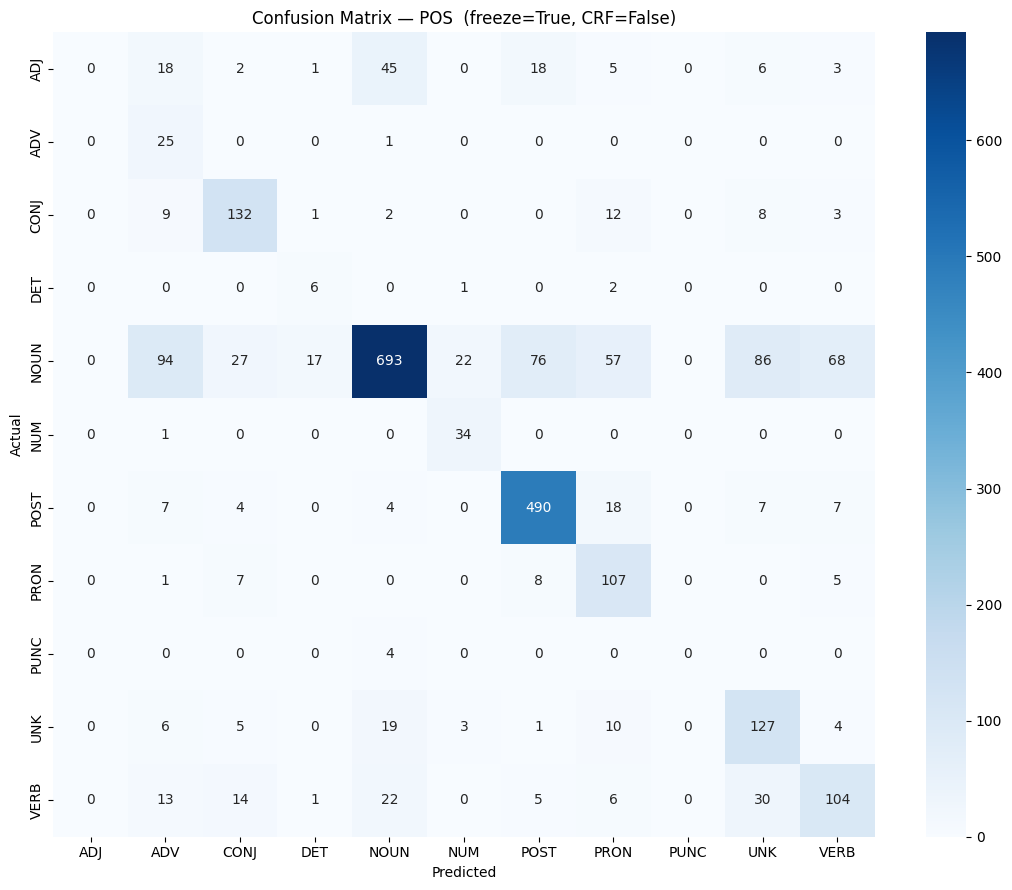


Top-3 most confused tag pairs (gold → predicted):
  NOUN   → ADV     (94 times)
  NOUN   → UNK     (86 times)
  NOUN   → POST    (76 times)

Example sentences per confused pair:
  [NOUN → POST]  token='نواز'  sentence: مریم | نواز | نے | ہدایت | جار | کی | کہ | نج | سیکٹر | کو | ورک | فرام | ہوم | لاگو | کرنے، | غیر | ضرور | تقریب | نہ | کرنے | اور | صرف | ضرور | سٹاف | بلانے | کی | ایڈوائزر | ایشو | کی | جائے
  [NOUN → UNK]  token='کرنے'  sentence: مریم | نواز | نے | ہدایت | جار | کی | کہ | نج | سیکٹر | کو | ورک | فرام | ہوم | لاگو | کرنے، | غیر | ضرور | تقریب | نہ | کرنے | اور | صرف | ضرور | سٹاف | بلانے | کی | ایڈوائزر | ایشو | کی | جائے
  [NOUN → UNK]  token='ایشو'  sentence: مریم | نواز | نے | ہدایت | جار | کی | کہ | نج | سیکٹر | کو | ورک | فرام | ہوم | لاگو | کرنے، | غیر | ضرور | تقریب | نہ | کرنے | اور | صرف | ضرور | سٹاف | بلانے | کی | ایڈوائزر | ایشو | کی | جائے
  [NOUN → ADV]  token='چند'  sentence: لیکن | چند | ہی | گھنٹ | کے | بعد، | اچانک، | بی | بی | سی | کے | انڈر | کور

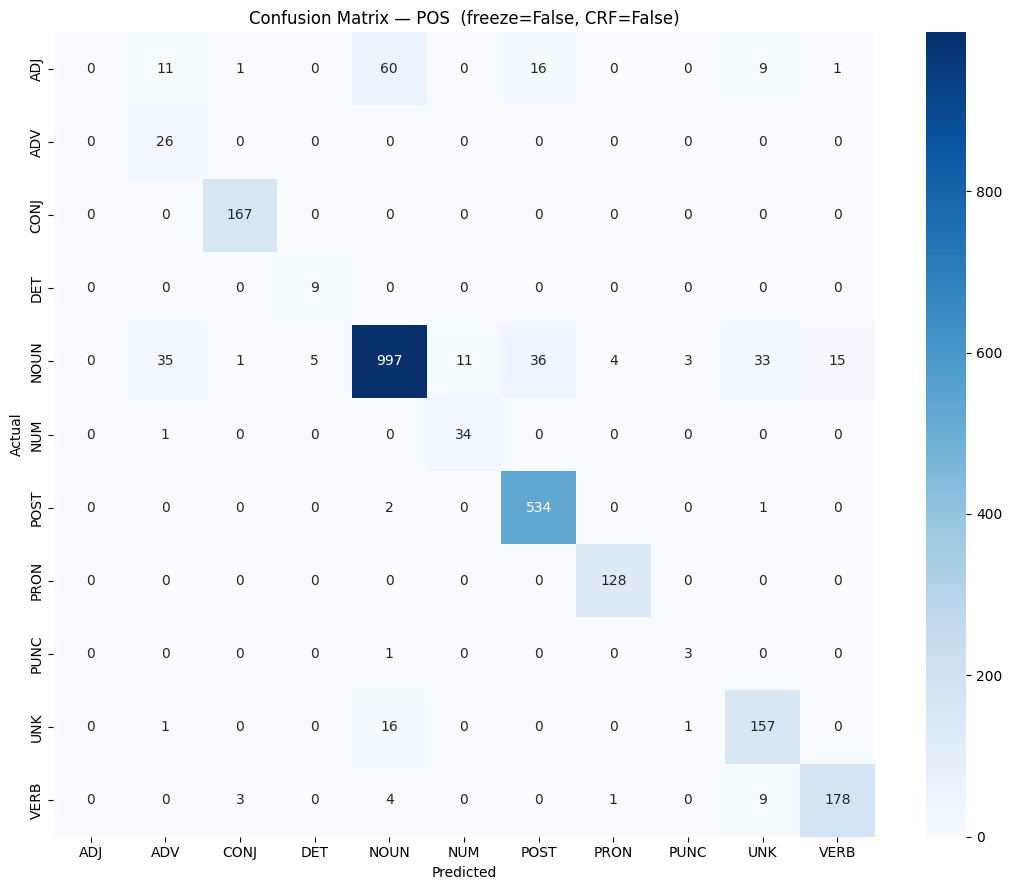


Top-3 most confused tag pairs (gold → predicted):
  ADJ    → NOUN    (60 times)
  NOUN   → POST    (36 times)
  NOUN   → ADV     (35 times)

Example sentences per confused pair:
  [NOUN → POST]  token='اچانک،'  sentence: لیکن | چند | ہی | گھنٹ | کے | بعد، | اچانک، | بی | بی | سی | کے | انڈر | کور | رپورٹر | کو | ایک | فون | آیا | اور | دوسر | طرف | سے | تنیشا | نام | خاتون | نے | اپ | تعارف | کروا | ہوئے | اردو | زب | میں | بات | چیت | کر | ہوئے | مدد | کی | پیشکش | کی | اور | ہم | جنس | پرس | کی | بنیاد | پر | برطانیہ | میں | پناہ | حاصل | کرنے | کے | حوالے | سے | بات | چیت | کی
  [NOUN → POST]  token='ہوئے'  sentence: لیکن | چند | ہی | گھنٹ | کے | بعد، | اچانک، | بی | بی | سی | کے | انڈر | کور | رپورٹر | کو | ایک | فون | آیا | اور | دوسر | طرف | سے | تنیشا | نام | خاتون | نے | اپ | تعارف | کروا | ہوئے | اردو | زب | میں | بات | چیت | کر | ہوئے | مدد | کی | پیشکش | کی | اور | ہم | جنس | پرس | کی | بنیاد | پر | برطانیہ | میں | پناہ | حاصل | کرنے | کے | حوالے | سے | بات | چیت | کی
  [AD

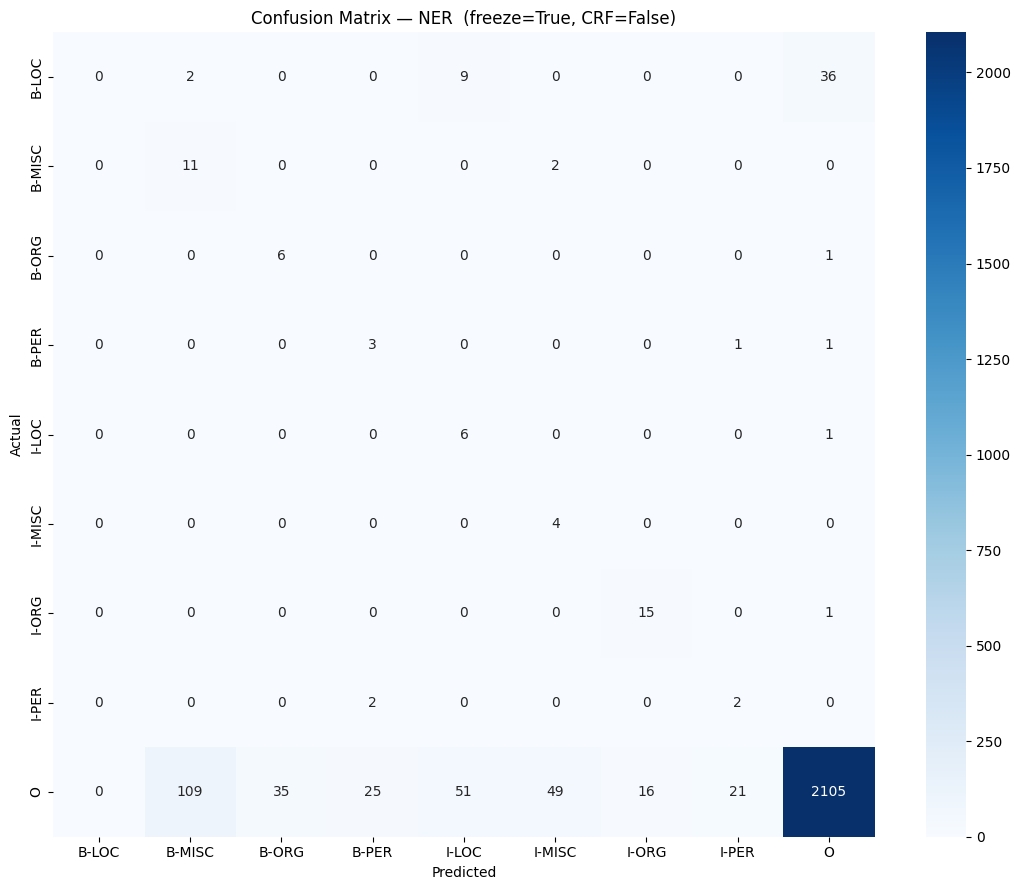


--- False Positives (predicted entity, actually O) ---
  Token: 'نے'  |  Gold: O  |  Pred: I-PER
  Sentence: مریم | نواز | نے | ہدایت | جار | کی | کہ | نج | سیکٹر | کو | ورک | فرام | ہوم | لاگو | کرنے، | غیر | ضرور | تقریب | نہ | کرنے | اور | صرف | ضرور | سٹاف | بلانے | کی | ایڈوائزر | ایشو | کی | جائے

  Token: 'ہدایت'  |  Gold: O  |  Pred: I-PER
  Sentence: مریم | نواز | نے | ہدایت | جار | کی | کہ | نج | سیکٹر | کو | ورک | فرام | ہوم | لاگو | کرنے، | غیر | ضرور | تقریب | نہ | کرنے | اور | صرف | ضرور | سٹاف | بلانے | کی | ایڈوائزر | ایشو | کی | جائے

  Token: 'کے'  |  Gold: O  |  Pred: B-ORG
  Sentence: لیکن | چند | ہی | گھنٹ | کے | بعد، | اچانک، | بی | بی | سی | کے | انڈر | کور | رپورٹر | کو | ایک | فون | آیا | اور | دوسر | طرف | سے | تنیشا | نام | خاتون | نے | اپ | تعارف | کروا | ہوئے | اردو | زب | میں | بات | چیت | کر | ہوئے | مدد | کی | پیشکش | کی | اور | ہم | جنس | پرس | کی | بنیاد | پر | برطانیہ | میں | پناہ | حاصل | کرنے | کے | حوالے | سے | بات | چیت | کی

  Token: 'بعد،'  |  

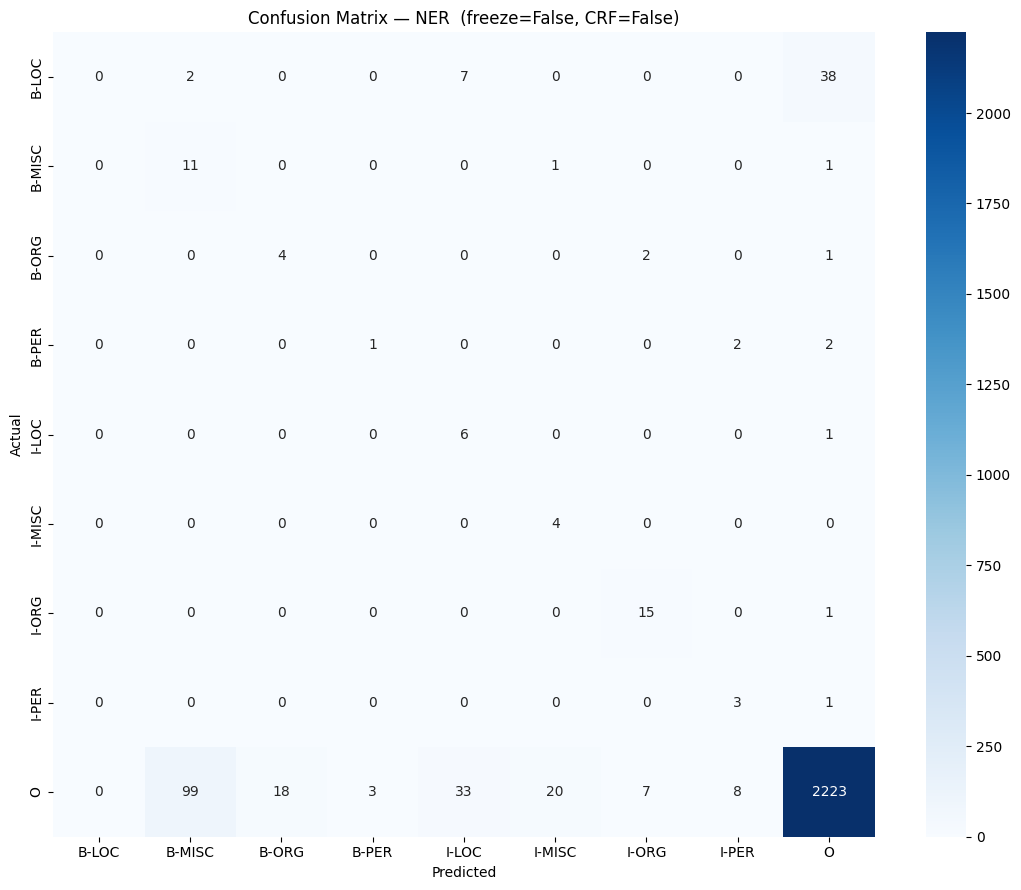


--- False Positives (predicted entity, actually O) ---
  Token: 'نے'  |  Gold: O  |  Pred: I-PER
  Sentence: مریم | نواز | نے | ہدایت | جار | کی | کہ | نج | سیکٹر | کو | ورک | فرام | ہوم | لاگو | کرنے، | غیر | ضرور | تقریب | نہ | کرنے | اور | صرف | ضرور | سٹاف | بلانے | کی | ایڈوائزر | ایشو | کی | جائے

  Token: 'ہدایت'  |  Gold: O  |  Pred: I-PER
  Sentence: مریم | نواز | نے | ہدایت | جار | کی | کہ | نج | سیکٹر | کو | ورک | فرام | ہوم | لاگو | کرنے، | غیر | ضرور | تقریب | نہ | کرنے | اور | صرف | ضرور | سٹاف | بلانے | کی | ایڈوائزر | ایشو | کی | جائے

  Token: 'کے'  |  Gold: O  |  Pred: B-ORG
  Sentence: لیکن | چند | ہی | گھنٹ | کے | بعد، | اچانک، | بی | بی | سی | کے | انڈر | کور | رپورٹر | کو | ایک | فون | آیا | اور | دوسر | طرف | سے | تنیشا | نام | خاتون | نے | اپ | تعارف | کروا | ہوئے | اردو | زب | میں | بات | چیت | کر | ہوئے | مدد | کی | پیشکش | کی | اور | ہم | جنس | پرس | کی | بنیاد | پر | برطانیہ | میں | پناہ | حاصل | کرنے | کے | حوالے | سے | بات | چیت | کی

  Token: 'بعد،'  |  

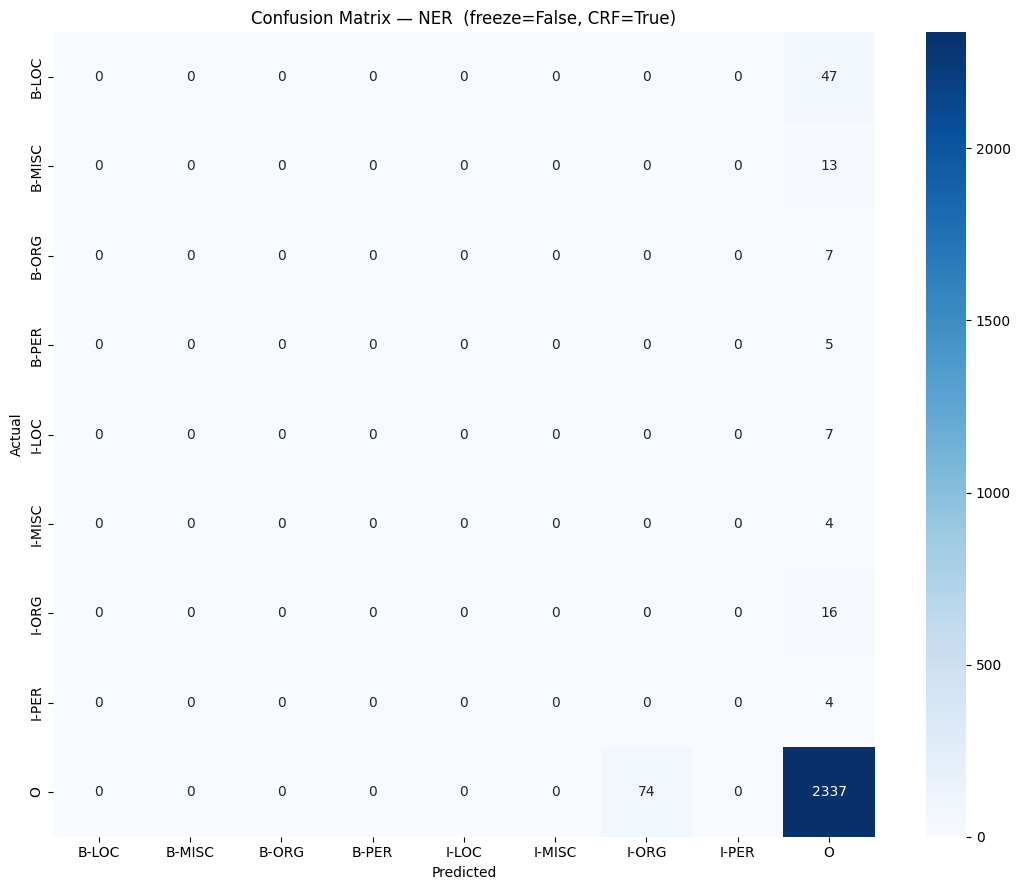


--- False Positives (predicted entity, actually O) ---
  Token: 'جائے'  |  Gold: O  |  Pred: I-ORG
  Sentence: مریم | نواز | نے | ہدایت | جار | کی | کہ | نج | سیکٹر | کو | ورک | فرام | ہوم | لاگو | کرنے، | غیر | ضرور | تقریب | نہ | کرنے | اور | صرف | ضرور | سٹاف | بلانے | کی | ایڈوائزر | ایشو | کی | جائے

  Token: 'ہے'  |  Gold: O  |  Pred: I-ORG
  Sentence: ہر | ماہ | کرایہ | بھ | آتا | رہ | ہے | اور | اپارٹمنٹ | کی | ویلیو | بھ | بڑھ | رہ | ہے

  Token: 'ہے'  |  Gold: O  |  Pred: I-ORG
  Sentence: حمزہ | نے | انھ | بتایا | کہ | وہ | اس | وقت | لاہور | کی | کیمپ | جیل | میں | ہیں | اور | انھ | بتایا | گیا | ہے | کہ | پیکا | کے | قانون | کے | تحت | انھ | پکڑا | گیا | ہے

  Token: 'تعلق'  |  Gold: O  |  Pred: I-ORG
  Sentence: اس | معاملے | پر | بات | کر | ہوئے | کابل | میں | تعین | رہنے | والے | پاکست | کے | سابق | سفیر | منصور | خان | نے | کہا | کہ | افغانست | میں | طالب | کی | حکومت | بننے | کے | بعد | پاکست | کی | ان | سے | دو | ہی | توقع | تھ | ایک | ٹی | ٹی | پی | کا | خاتمہ | او

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import numpy as np
import subprocess, tempfile, os

# ──────────────────────────────────────────────
# HELPER: run conlleval on NER predictions
# ──────────────────────────────────────────────
def run_conlleval(tokens_list, golds_list, preds_list, idx2tag):
    """Write a CoNLL-format temp file and run conlleval.pl (or the Python port)."""
    lines = []
    for tokens, golds, preds in zip(tokens_list, golds_list, preds_list):
        for tok, g, p in zip(tokens, golds, preds):
            gold_tag = idx2tag[g]
            pred_tag = idx2tag[p]
            lines.append(f"{tok} {gold_tag} {pred_tag}")
        lines.append("")          # sentence boundary

    # Try the seqeval library (pip install seqeval) — no Perl needed
    try:
        from seqeval.metrics import classification_report as seq_report
        from seqeval.metrics import precision_score, recall_score, f1_score as seq_f1

        gold_seqs = [[idx2tag[g] for g in gs] for gs in golds_list]
        pred_seqs = [[idx2tag[p] for p in ps] for ps in preds_list]

        print("\n--- Entity-level NER Report (seqeval / conlleval-style) ---")
        print(seq_report(gold_seqs, pred_seqs, zero_division=0))
    except ImportError:
        # Fallback: print the raw CoNLL lines so the user can run conlleval manually
        print("\n[seqeval not installed — install with: pip install seqeval]")
        print("CoNLL output (first 20 lines):")
        print("\n".join(lines[:20]))


# ──────────────────────────────────────────────
# HELPER: find top confused tag pairs
# ──────────────────────────────────────────────
def top_confused_pairs(cm, target_names, n=3):
    """Return the n most confused off-diagonal (gold, pred) tag pairs."""
    cm_copy = cm.copy().astype(float)
    np.fill_diagonal(cm_copy, 0)          # zero the diagonal (correct predictions)
    pairs = []
    for _ in range(n):
        idx = np.unravel_index(cm_copy.argmax(), cm_copy.shape)
        pairs.append((target_names[idx[0]], target_names[idx[1]], int(cm_copy[idx])))
        cm_copy[idx] = 0
    return pairs


# ──────────────────────────────────────────────
# HELPER: false positive / negative error analysis
# ──────────────────────────────────────────────
def ner_error_analysis(tokens_list, golds_list, preds_list, idx2tag, n=5):
    """Print n false positives and n false negatives with sentence context."""
    fps, fns = [], []

    for tokens, golds, preds in zip(tokens_list, golds_list, preds_list):
        sentence = " | ".join(tokens)
        for j, (g, p) in enumerate(zip(golds, preds)):
            g_tag, p_tag = idx2tag[g], idx2tag[p]
            is_o_gold = (g_tag == "O")
            is_o_pred = (p_tag == "O")

            # False positive: model predicted an entity where there is none
            if is_o_gold and not is_o_pred and len(fps) < n:
                fps.append((tokens[j], g_tag, p_tag, sentence))

            # False negative: model missed a real entity
            if not is_o_gold and is_o_pred and len(fns) < n:
                fns.append((tokens[j], g_tag, p_tag, sentence))

        if len(fps) >= n and len(fns) >= n:
            break

    print("\n--- False Positives (predicted entity, actually O) ---")
    for tok, gold, pred, sent in fps:
        print(f"  Token: '{tok}'  |  Gold: {gold}  |  Pred: {pred}")
        print(f"  Sentence: {sent}\n")

    print("--- False Negatives (missed entity, predicted O) ---")
    for tok, gold, pred, sent in fns:
        print(f"  Token: '{tok}'  |  Gold: {gold}  |  Pred: {pred}")
        print(f"  Sentence: {sent}\n")


# ──────────────────────────────────────────────
# MAIN EVALUATE FUNCTION
# ──────────────────────────────────────────────
def evaluate(task="pos", freeze=False, use_crf=False):
    print(f"\n{'='*55}")
    print(f"EVALUATING: Task={task.upper()} | Frozen={freeze} | CRF={use_crf}")
    print(f"{'='*55}")

    tag_map     = pos2idx if task == "pos" else ner2idx
    sorted_tags = sorted(tag_map.items(), key=lambda x: x[1])
    target_names = [tag for tag, _ in sorted_tags]
    idx2tag      = {v: k for k, v in tag_map.items()}

    # ── Load model ──────────────────────────────
    loader = DataLoader(
        SeqDataset(test_data, vocab, tag_map, task),
        batch_size=32, collate_fn=collate
    )
    embeddings = np.load("embeddings_w2v.npy")
    model = BiLSTM_CRF(embeddings, 128, len(tag_map), freeze, use_crf)
    model.load_state_dict(
        torch.load(f"{task}_{freeze}_{use_crf}.pt", map_location=device)
    )
    model.to(device)
    model.eval()

    preds, golds = [], []
    # Keep per-sentence data for NER entity-level eval and error analysis
    sent_tokens, sent_golds, sent_preds = [], [], []

    # ── Inference ───────────────────────────────
    with torch.no_grad():
        sent_idx = 0
        for x, y, mask in loader:
            x, y, mask = x.to(device), y.to(device), mask.to(device)

            if use_crf:
                # FIX: pass mask.bool() — float mask causes the bool-subtraction error
                pred_seqs = model(x, mask=mask.bool())
                for i, pred_seq in enumerate(pred_seqs):
                    valid_len = len(pred_seq)
                    p = pred_seq
                    g = y[i, :valid_len].cpu().tolist()
                    preds.extend(p)
                    golds.extend(g)
                    sent_preds.append(p)
                    sent_golds.append(g)
                    sent_tokens.append(test_data[sent_idx]["tokens"][:valid_len])
                    sent_idx += 1
            else:
                out  = model(x)
                pred = out.argmax(-1)
                for i in range(x.size(0)):
                    valid_len = int(mask[i].sum().item())
                    p = pred[i, :valid_len].cpu().tolist()
                    g = y[i,   :valid_len].cpu().tolist()
                    preds.extend(p)
                    golds.extend(g)
                    sent_preds.append(p)
                    sent_golds.append(g)
                    sent_tokens.append(test_data[sent_idx]["tokens"][:valid_len])
                    sent_idx += 1

    # ── Token-level report (both tasks) ─────────
    print("\nToken-level Classification Report:")
    print(classification_report(
        golds, preds, target_names=target_names, zero_division=0
    ))

    # ── Entity-level report (NER only) ──────────
    if task == "ner":
        run_conlleval(sent_tokens, sent_golds, sent_preds, idx2tag)

    # ── Confusion matrix ────────────────────────
    cm = confusion_matrix(golds, preds, labels=list(range(len(tag_map))))
    plt.figure(figsize=(11, 9))
    sns.heatmap(
        cm, annot=True, fmt='d',
        xticklabels=target_names, yticklabels=target_names,
        cmap='Blues'
    )
    plt.title(f"Confusion Matrix — {task.upper()}  (freeze={freeze}, CRF={use_crf})")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    # ── Top-3 confused pairs (POS only) ─────────
    if task == "pos":
        print("\nTop-3 most confused tag pairs (gold → predicted):")
        for gold_tag, pred_tag, count in top_confused_pairs(cm, target_names):
            print(f"  {gold_tag:6} → {pred_tag:6}  ({count} times)")

        # Example sentences for each confused pair
        print("\nExample sentences per confused pair:")
        top_pairs = [(g, p) for g, p, _ in top_confused_pairs(cm, target_names)]
        shown = {pair: 0 for pair in top_pairs}

        for sent_g, sent_p, tokens in zip(sent_golds, sent_preds, sent_tokens):
            for g_idx, p_idx, tok in zip(sent_g, sent_p, tokens):
                pair = (idx2tag[g_idx], idx2tag[p_idx])
                if pair in shown and shown[pair] < 2:
                    print(f"  [{pair[0]} → {pair[1]}]  token='{tok}'  sentence: {' | '.join(tokens)}")
                    shown[pair] += 1

    # ── NER error analysis ───────────────────────
    if task == "ner":
        ner_error_analysis(sent_tokens, sent_golds, sent_preds, idx2tag)

    return golds, preds, target_names, cm


# ──────────────────────────────────────────────
# RUN ALL EVALUATIONS + SUMMARY TABLE
# ──────────────────────────────────────────────
results = {}

# POS
g, p, names, _ = evaluate("pos", freeze=True,  use_crf=False)
results["POS frozen"]    = precision_recall_fscore_support(g, p, average="macro", zero_division=0)

g, p, names, _ = evaluate("pos", freeze=False, use_crf=False)
results["POS fine-tuned"] = precision_recall_fscore_support(g, p, average="macro", zero_division=0)

# NER
g, p, names, _ = evaluate("ner", freeze=True,  use_crf=False)
results["NER frozen, no CRF"]    = precision_recall_fscore_support(g, p, average="macro", zero_division=0)

g, p, names, _ = evaluate("ner", freeze=False, use_crf=False)
results["NER fine-tuned, no CRF"] = precision_recall_fscore_support(g, p, average="macro", zero_division=0)

g, p, names, _ = evaluate("ner", freeze=False, use_crf=True)
results["NER fine-tuned, CRF"]   = precision_recall_fscore_support(g, p, average="macro", zero_division=0)

# ── Summary table ───────────────────────────────
print("\n" + "="*65)
print(f"{'SUMMARY TABLE'}")
print("="*65)
print(f"{'Configuration':<28} {'Precision':>10} {'Recall':>8} {'Macro-F1':>10}")
print("-"*65)
for name, (prec, rec, f1, _) in results.items():
    print(f"{name:<28} {prec:>10.3f} {rec:>8.3f} {f1:>10.3f}")
print("="*65)

In [6]:
import json, random
from collections import Counter, defaultdict

random.seed(42)

# ── 1. LOAD METADATA ────────────────────────────────────────────
def load_metadata(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

metadata = load_metadata("metadata.json")

# ── 2. LOAD CLEANED DOCS (one doc per article) ──────────────────
def load_cleaned_docs(path):
    """Returns list of (article_number, token_list) in file order."""
    docs = []
    current_article = None
    current_tokens  = []

    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line.startswith("Article"):
                if current_article is not None:
                    docs.append((current_article, current_tokens))
                # parse "Article 3" → "3"
                current_article = line.split()[-1]
                current_tokens  = []
            elif line:
                tokens = [t.strip() for t in line.split('|') if t.strip()]
                current_tokens.extend(tokens)

    if current_article is not None:          # flush last article
        docs.append((current_article, current_tokens))

    return docs

raw_docs = load_cleaned_docs("cleaned.txt")
print(f"Loaded {len(raw_docs)} articles from cleaned.txt")

# ── 3. CATEGORY KEYWORDS (Urdu — broad coverage) ────────────────
CATEGORY_KEYWORDS = {
    "Politics": [
        "حکومت", "وزیر", "وزیراعظم", "سیاست", "پارلیمنٹ", "اسمبلی", "سینیٹ",
        "انتخاب", "ووٹ", "جماعت", "پارٹی", "اپوزیشن", "وزارت", "کابینہ",
        "وزیراعلیٰ", "گورنر", "صدر", "فوج", "آرمی", "مارشل", "عدالت",
        "سپریم کورٹ", "ہائیکورٹ", "گرفتار", "مقدمہ", "احتجاج", "مظاہرہ",
        "شہباز", "عمران", "نواز", "بلاول", "زرداری", "پی ٹی آئی", "ن لیگ",
    ],
    "Sports": [
        "کرکٹ", "میچ", "ٹیم", "کھلاڑی", "اسکور", "وکٹ", "رن", "اوور",
        "فٹبال", "ہاکی", "ٹینس", "ریس", "ٹورنامنٹ", "چیمپئن", "فتح",
        "شکست", "کپتان", "پی ایس ایل", "ورلڈ کپ", "سیریز", "کوچ",
        "اسٹیڈیم", "کھیل", "ایتھلیٹ", "میڈل",
    ],
    "Economy": [
        "قیمت", "بجٹ", "روپے", "مہنگائی", "تجارت", "بینک", "معیشت",
        "آئی ایم ایف", "قرض", "ٹیکس", "لیوی", "سبسڈی", "پیٹرول", "ڈیزل",
        "گیس", "بجلی", "لوڈ شیڈنگ", "برآمد", "درآمد", "ڈالر", "شرح",
        "سرمایہ", "کاروبار", "صنعت", "زراعت", "کسان", "مارکیٹ",
        "ریلویز", "پی آئی اے", "نجکاری", "فیکٹری",
    ],
    "International": [
        "امریکہ", "چین", "ایران", "اسرائیل", "افغانستان", "انڈیا", "سعودی",
        "ترکی", "روس", "یورپ", "اقوام متحدہ", "معاہدہ", "سفارت", "ثالثی",
        "مذاکرات", "جنگ", "جنگ بندی", "حملہ", "ڈرون", "میزائل",
        "دہشت گردی", "طالبان", "داعش", "ٹرمپ", "بائیڈن", "پوتن",
        "بین الاقوامی", "سفیر", "خلیج", "آبنائے", "ناٹو",
    ],
    "Health & Society": [
        "ہسپتال", "تعلیم", "بیماری", "وبا", "ویکسین", "ڈاکٹر", "علاج",
        "سیلاب", "زلزلہ", "آفت", "امداد", "بچہ", "خاتون", "خواتین",
        "اسکول", "یونیورسٹی", "سماجی", "غربت", "بے روزگاری", "جرم",
        "قتل", "عصمت دری", "انسانی حقوق", "ماحول", "موسم", "پانی",
        "صحت", "انجکشن", "وائرس", "ایچ آئی وی",
    ],
}

# ── 4. CLASSIFY USING METADATA TITLE + DOC TOKENS ───────────────
def assign_category(article_id, doc_tokens):
    """
    Score each category against:
      - the article's Urdu title from metadata  (weight × 3 — titles are dense signals)
      - the body tokens from cleaned.txt         (weight × 1)
    """
    title_text = ""
    if article_id in metadata:
        title_text = metadata[article_id].get("title", "")

    body_text = " ".join(doc_tokens)
    scores = {cat: 0 for cat in CATEGORY_KEYWORDS}

    for cat, keywords in CATEGORY_KEYWORDS.items():
        for kw in keywords:
            if kw in title_text:
                scores[cat] += 3          # title match is worth more
            if kw in body_text:
                scores[cat] += 1

    best  = max(scores, key=scores.get)
    total = sum(scores.values())

    if total == 0:
        return "Politics"                 # informed default (majority class)
    return best

labels = [assign_category(art_id, tokens) for art_id, tokens in raw_docs]

print("\nLabel distribution BEFORE split:")
dist = Counter(labels)
for cat, cnt in sorted(dist.items()):
    print(f"  {cat:<20}: {cnt}")

# ── 8. REPORT DISTRIBUTIONS ─────────────────────────────────────
def report_split(split, name):
    counts = Counter(idx2cat[y] for _, y in split)
    total  = len(split)
    print(f"\n{name} ({total} articles):")
    for cat in sorted(counts):
        pct = 100 * counts[cat] / total
        print(f"  {cat:<20}: {counts[cat]:>4}  ({pct:.1f}%)")

report_split(train_data, "Train")
report_split(val_data,   "Validation")
report_split(test_data,  "Test")

print(f"\nEncoded shape check: {len(train_data[0][0])} token IDs per document (expected {MAX_LEN})")

In [ ]:
import math
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import matplotlib.pyplot as plt

# ── CONSTANTS ────────────────────────────────────────────────────
MAX_LEN   = 256
D_MODEL   = 128
N_HEADS   = 4
D_K       = D_MODEL // N_HEADS   # 32
D_FF      = 512
N_LAYERS  = 4
N_CLASSES = 5
WARMUP    = 50
EPOCHS    = 20
BATCH     = 32
LR        = 5e-4

# ── DATASET ──────────────────────────────────────────────────────
class TransformerDataset(Dataset):
    def __init__(self, data):
        self.data = data          # list of (token_id_list, int_label)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x, y = self.data[idx]
        # x is already padded/truncated to MAX_LEN by encode() — just tensor-ify
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)

# ── ATTENTION ────────────────────────────────────────────────────
class ScaledDotProductAttention(nn.Module):
    def __init__(self, d_k):
        super().__init__()
        self.scale = math.sqrt(d_k)

    def forward(self, Q, K, V, mask=None):
        # Q/K/V: (B, heads, T, d_k)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale   # (B, heads, T, T)
        if mask is not None:
            # mask: (B, 1, 1, T) — True where padding, fill with -inf
            scores = scores.masked_fill(mask, -1e9)
        attn   = torch.softmax(scores, dim=-1)
        output = torch.matmul(attn, V)                                # (B, heads, T, d_k)
        return output, attn


# ── MULTI-HEAD ATTENTION ─────────────────────────────────────────
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model=D_MODEL, heads=N_HEADS, d_k=D_K):
        super().__init__()
        self.heads = heads
        self.d_k   = d_k

        self.W_q = nn.Linear(d_model, heads * d_k, bias=False)
        self.W_k = nn.Linear(d_model, heads * d_k, bias=False)
        self.W_v = nn.Linear(d_model, heads * d_k, bias=False)
        self.fc  = nn.Linear(heads * d_k, d_model, bias=False)

        self.attention = ScaledDotProductAttention(d_k)

    def forward(self, x, mask=None):
        B, T, _ = x.shape

        Q = self.W_q(x).view(B, T, self.heads, self.d_k).transpose(1, 2)  # (B,h,T,dk)
        K = self.W_k(x).view(B, T, self.heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.heads, self.d_k).transpose(1, 2)

        out, attn = self.attention(Q, K, V, mask)

        out = out.transpose(1, 2).contiguous().view(B, T, -1)   # (B, T, h*dk)
        return self.fc(out), attn


# ── FEED-FORWARD ─────────────────────────────────────────────────
class FeedForward(nn.Module):
    def __init__(self, d_model=D_MODEL, d_ff=D_FF):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model),
        )

    def forward(self, x):
        return self.net(x)


# ── SINUSOIDAL POSITIONAL ENCODING ───────────────────────────────
class PositionalEncoding(nn.Module):
    """Fixed (non-learned) sinusoidal encoding stored as a buffer."""
    def __init__(self, d_model=D_MODEL, max_len=MAX_LEN + 1):  # +1 for CLS token
        super().__init__()
        pe       = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.pow(
            10000.0, torch.arange(0, d_model, 2, dtype=torch.float) / d_model
        )
        pe[:, 0::2] = torch.sin(position / div_term)
        pe[:, 1::2] = torch.cos(position / div_term)
        self.register_buffer("pe", pe.unsqueeze(0))   # (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]
